# Imports

In [20]:
import json
import glob
import pandas
import matplotlib.pyplot as plt
import os
import itertools

# Improve Data Organization
The data set currently exists as a folder with a collection of .jsons. The format of the .json is very data rich, but not condusive to being read as a table. So, the first step of cleaning the data will be to improve the formating in order to elimate data duplication and improve future readability of the .json files and the code that works with them.

## Create AllCardsUUID.json
This will be a single .json file with every unique card in the data set, so that the deck .json files can be slimmed to include only references to the card data rather than duplicating the data each time. An important step is to not save any values to our AllCardsUUID.json file that are unique to its occurance in the deck. We can also move reduntant data like the foreignData, which just gives us the same information but in different languages.

In [2]:
CARD_SECTIONS = ['commander', 'displayCommander', 'mainBoard', 'sideBoard', 'planes', 'schemes', 'tokens']
PRUNE_ATTRIBUTES = {'foreignData', 'language', 'hasFoil', 'hasNonFoil'}
OCCURENCE_SPECIFIC_ATTRIBUTES = {'count', 'isFoil', 'isEtched'}
DATA_PATH = '../Data/'
ENCODING = 'utf-8'

### A chance to improve data quality
This can also serve as an opportunity to improve data quality. Some instances of a cards appeareance may be lacking a particular value that another instance has. By associating the two occurances we can get values for some missing attributes and standardize the data type of these attributes.

In [3]:
def is_sublist(a, b):
    return all(item in b for item in a)

In [4]:
def update_missing_values(existing: dict, new: dict, IGNORE_ATTRIBUTES) -> None:
    updates = 0
    for k, v in new.items():
        if any(k in i for i in IGNORE_ATTRIBUTES):
            continue
        if v is None or v == '' or v == []:
            continue
        if k not in existing:
            existing[k] = v
            updates += 1
            print(f'Missing key filled {k} = {v}')
        elif existing[k] is None or existing[k] == '' or existing[k] == []:
            existing[k] = v
            updates += 1
            print(f'Empty value filled{k} = {v}')
        elif existing[k] != v:
            if isinstance(existing[k], list) and isinstance(v, list): #Automatically accept updates that contain the original as a sublist
                merged = list({str(item): item for item in existing[k] + v}.values())
                if merged != existing[k]:
                    existing[k] = merged
                    updates += 1
                continue
            elif isinstance(existing[k], dict) and isinstance(v, dict):
                merged = {**v, **existing[k]}  # existing takes priority on conflicts
                if merged != existing[k]:
                    existing[k] = merged
                    updates += 1
                continue
            print(f"\nConflict for key '{k}':")
            print(f"  [1] Keep existing: {existing[k]}")
            print(f"  [2] Use new:       {v}")
            print(f"  [3] Skip (keep existing, don't count as fix)")
            choice = input("Choose 1/2/3: ").strip()
            if choice == '2':
                existing[k] = v
                updates += 1
            elif choice == '3':
                pass
            else:  # default to keeping existing
                pass
    return updates

In [5]:
fixed_value_count = 0
card_collection = {}
for filepath in glob.glob(f'{DATA_PATH}AllDeckFiles(Experimental)/*.json'):
    with open(filepath, 'r', encoding=ENCODING) as f:
        data = json.load(f)['data']

    for section in CARD_SECTIONS:
        for card in data.get(section, []):
            uuid = card['uuid']
            if uuid not in card_collection:
                card_collection[uuid] = {k: v for k, v in card.items() if k not in PRUNE_ATTRIBUTES and k not in OCCURENCE_SPECIFIC_ATTRIBUTES}
            else:
                fixed_value_count += update_missing_values(card_collection[uuid],card, PRUNE_ATTRIBUTES | OCCURENCE_SPECIFIC_ATTRIBUTES)
                

with open(f'{DATA_PATH}AllCardsUUID.json', 'w', encoding=ENCODING) as f:
    json.dump(card_collection, f, indent=2)

card_uuid_df = pandas.json_normalize(card_collection.values())
card_uuid_df.index = list(card_collection.keys())

if fixed_value_count == 0:
    print("No missing values were filled by other occurances.\nNo non occurance-specific data was conflicting.")
else:
    print(f"{fixed_value_count} Values were fixed")

No missing values were filled by other occurances.
No non occurance-specific data was conflicting.


### Example of AllCardsUUID.json rows

In [6]:
print_columns = ['uuid','name','manaValue','text']
card_uuid_df[print_columns]

,uuid,name,manaValue,text
8fa8096a-91c3-5755-8ec5-9be33e36618c,8fa8096a-91c3-5755-8ec5-9be33e36618c,Plains,0.0,({T}: Add {W}.)
7fdc4047-429c-53df-bb8d-809c1477c00f,7fdc4047-429c-53df-bb8d-809c1477c00f,Island,0.0,({T}: Add {U}.)
b7791452-37bd-5ce3-ac83-d53660e0adbd,b7791452-37bd-5ce3-ac83-d53660e0adbd,Swamp,0.0,({T}: Add {B}.)
ab1c9ddc-a955-5952-921a-fe55cd597522,ab1c9ddc-a955-5952-921a-fe55cd597522,Mountain,0.0,({T}: Add {R}.)
e429c73c-7254-520a-87dd-2c2da91a3f4e,e429c73c-7254-520a-87dd-2c2da91a3f4e,Forest,0.0,({T}: Add {G}.)
...,...,...,...,...
77188a9d-813a-55a8-b12f-17e5028427c4,77188a9d-813a-55a8-b12f-17e5028427c4,Horror of Horrors,5.0,Sacrifice a Swamp: Regenerate target black cre...
2c0dd16b-8164-5d67-8146-69bef3f69ba9,2c0dd16b-8164-5d67-8146-69bef3f69ba9,Mind Slash,3.0,"{B}, Sacrifice a creature: Target opponent rev..."
6ab462c8-d190-53c2-9dd0-1d0bc9e06024,6ab462c8-d190-53c2-9dd0-1d0bc9e06024,Necromantic Thirst,4.0,Enchant creature\nWhenever enchanted creature ...
2b0c0e55-c4e4-523a-bfad-b2b75b6a6168,2b0c0e55-c4e4-523a-bfad-b2b75b6a6168,"Zuko, Firebending Master",2.0,"First strike\nFirebending X, where X is the nu..."


### Actual Length
Below is the actual length of the card_uuid_df data frame.

In [7]:
len(card_uuid_df.columns)

134

## Create AllCardsName.json
A feature of the AllCardsUUID.json is that it treats every printing of a card as its own entirely unique card. I imagine this will be useful for some parts of analysis, but does not map to how players of the games treat the uniqueness of a card. In MTG the uniqueness of a card is decided soley by the name of the card. This means to truly track the presence of a card between decks we need another file that associates all printings of a card under the name.

In [8]:
card_collection_name = {}
with open(f'{DATA_PATH}AllCardsUUID.json', 'r', encoding=ENCODING) as f:
    data = json.load(f)

for uuid, card in data.items():
    name = ''
    if card['layout'] == 'token': #Needed to catch tokens that share names with actual cards like Shapeshifter
        name = f'{card['name']} (Token-{card['colorIdentity']})'
    else:
        name = card['name']
    if name not in card_collection_name:
        card_collection_name[name] = {'uuids' : [uuid] }
    elif uuid not in card_collection_name[name]:
        card_collection_name[name]['uuids'].append(card['uuid'])

### New Data
We also need to create new data that is specific to the card by name.

In [ ]:
NAME_SPECIFIC_ATTRIBUTES = {'asciiName', 'colorIdentity', 'colorIndicator', 'colors', 'defense', 'edhrecRank', 'edhrecSaltiness', 'faceManaValue', 'hand', 
                            'hasAlternativeDeckLimit', 'isGameChanger', 'isRebalanced', 'keyWords', 'leadershipSkills', 'life', 'loyalty', 'manaCost', 'manaValue',
                            'power', 'rebalancedPrintings', 'subtypes', 'superTypes', 'text', 'toughness', 'types'}

BRAWL_BANNED_CARDS = ['Agent of Treachery', 'Ancient Tomb', 'Chalice of the Void', 'Channel', 'Chrome Mox', 'Demonic Tutor', 'Drannith Magistrate', 
                                      'Field of the Dead', "Gideon's Intervention", 'Lutri, the Spellchaser', 'Mana Drain', 'Meddling Mage', 'Natural Order', 'Nexus of Fate', 
                                      'Oko, Thief of Crowns', 'Phyrexian Revoker', 'Pithing Needle', 'Runed Halo', 'Sorcerous Spyglass', 'Strip Mine', 'Tainted Pact', 
                                      'Ugin, the Spirit Dragon']


total_fixes = 0
for name, data in card_collection_name.items():
    for attribute in NAME_SPECIFIC_ATTRIBUTES:
        conflicts = []
        for uuid in data['uuids']:
            if attribute not in card_collection[uuid]:
                continue
            if attribute not in data:
                data[attribute] = card_collection[uuid][attribute]
                continue
            elif data[attribute] == card_collection[uuid][attribute]:
                continue
            else:
                if card_collection[uuid][attribute] not in conflicts:
                    conflicts.append(card_collection[uuid][attribute])
        if len(conflicts) > 0:
            if attribute == 'leadershipSkills': #A majority of conflicts were centered around the cards legality as a commander in brawl, so I do them all automamtically
                if name in BRAWL_BANNED_CARDS:
                    data[attribute]['brawl'] = False
                elif data[attribute]['commander']:
                    data[attribute]['brawl'] = True
            else:
                conflicts.append(data[attribute])
                print(f'missmatch of {attribute} in {name}')
                i = 0
                for conflict in conflicts:
                    print(f'[{i}] {conflict}')
                    i += 1
                print(f'{[i]} Input a new value')
                choice = (int)(input("Choose from above: ").strip())
                if (choice < 0 or choice > (i-1)) and isinstance(choice, (int, float, str)):
                    target_type = type(data[attribute])
                    input_value = target_type(input("New value: ").strip())
                    data[attribute] = input_value
                else:
                    data[attribute] = conflicts[choice]
                
            


missmatch of toughness in Snake // Zombie
[0] 1
[1] 2
[2] *
[3] Input a new value


Choose from above:  2


missmatch of power in Snake // Zombie
[0] 1
[1] 2
[2] *
[3] Input a new value


Choose from above:  2


missmatch of subtypes in Snake // Zombie
[0] ['Snake']
[1] ['Zombie']
[2] ['[', "'", 'Z', 'o', 'm', 'b', 'i', 'e', "'", ',', "'", 'S', 'n', 'a', 'k', 'e', "'", ']']
[3] Input a new value


### Results

In [12]:
with open(f'{DATA_PATH}AllCardsName.json', 'w', encoding=ENCODING) as f:
    json.dump(card_collection_name, f, indent=2)

with open(f'{DATA_PATH}AllCardsName.json', 'w', encoding=ENCODING) as f:
    json.dump(card_collection_name, f, indent=2)

card_name_df = pandas.read_json(f'{DATA_PATH}AllCardsName.json', orient='index')

### Reducing Cardinality
Before associating cards by name, we had 54,167 unique cards. After associating by name, the amount of unique cards has been more than halved down to 26,342. A large amount of this simplification happens in the association of the different printings of basic land cards. Before we had 662 Plains, 685 Islands, 676 Swamps, 683 Mountains, and 725 mountains. With just the lands we have reduced 3,431 different cards into just 5. This means of the remaining 50,736 non basic land cards we have simplified to 26,337 for a 48.1% reduction in cardinality.

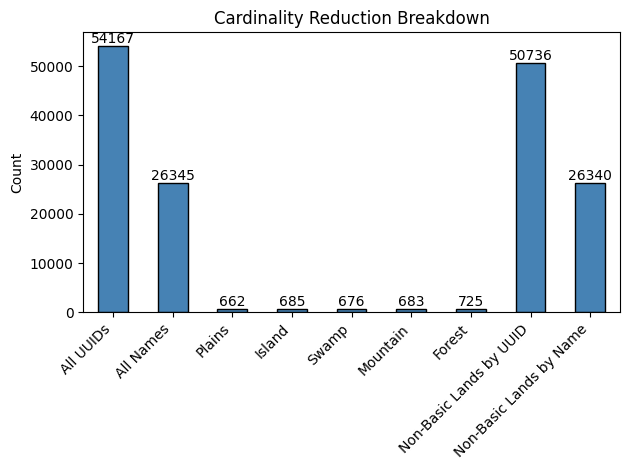

In [13]:
BASIC_LANDS = ['Plains','Island','Swamp','Mountain','Forest']
basic_land_counts = {land: len (card_collection_name[land]['uuids']) for land in BASIC_LANDS}

labels = ['All UUIDs','All Names',
          'Plains',
          'Island',
          'Swamp',
          'Mountain',
          'Forest',
          'Non-Basic Lands by UUID',
          'Non-Basic Lands by Name']
values = [len(card_collection), 
          len(card_collection_name), 
          basic_land_counts['Plains'], 
          basic_land_counts['Island'], 
          basic_land_counts['Swamp'],
          basic_land_counts['Mountain'],
          basic_land_counts['Forest'],
          len(card_collection) - sum(basic_land_counts.values()),
          len(card_collection_name) - len(basic_land_counts)]

ax = pandas.Series(values, index=labels).plot(kind='bar', color='steelblue', edgecolor='black')
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()), ha='center', va='bottom')
plt.title('Cardinality Reduction Breakdown')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## Slimming the AllDeckFiles .json files.
Now that we have to different tables that can store the data referenced in the deck files, we can slim down the size of the deck files by replacing all instances of a card with a UUID and Name that serve as references to the AllCardsUUID.json and AllCardsName.json files respectively.

In [17]:
for filepath in glob.glob(f'{DATA_PATH}AllDeckFiles(Experimental)/*.json'):
    with open(filepath, 'r', encoding=ENCODING) as f:
        raw = json.load(f)

    data = raw['data']
    for section in CARD_SECTIONS:
        if section in data:
            data[section] = [{'uuid' : card['uuid'], 
                              'name' : card['name'], 
                              'count' : card['count'],
                              'isFoil' : card.get('isFoil'),
                              'isEtched' : card.get('isEtched')} 
                             for card in data[section]]

    filename = os.path.basename(filepath)
    with open(f'{DATA_PATH}AllDeckFiles(Slim)/{filename}', 'w', encoding=ENCODING) as f:
        json.dump(raw, f, indent=2)

### Comparison of Attribute Count
By swaping the data duplication for references, the ammount of attributes in each deck file (meaning the amount of attributes in each row of our data) has been reduced from 7,252 to 532. 

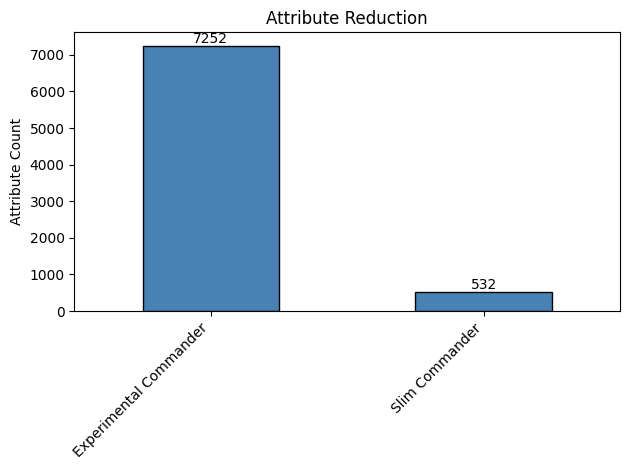

In [19]:
experimental_file_commander = f'{DATA_PATH}AllDeckFiles(Experimental)/20WaystoWin_SLD.json'
slim_file_commander = f'{DATA_PATH}AllDeckFiles(Slim)/20WaystoWin_SLD.json'

def count_all_attributes(obj):
    count = 0
    if isinstance(obj, dict):
        count += len(obj.keys())
        for value in obj.values():
            count += count_all_attributes(value)
    elif isinstance(obj, list):
        for item in obj:
            count += count_all_attributes(item)
    return count

def get_total_attributes(filepath):
    with open(filepath, 'r', encoding=ENCODING) as f:
        raw = json.load(f)
    return count_all_attributes(raw)

experimental_count_commander = get_total_attributes(experimental_file_commander)
slim_count_commander = get_total_attributes(slim_file_commander)

labels = ['Experimental Commander',
          'Slim Commander']
values = [experimental_count_commander,
          slim_count_commander]

ax = pandas.Series(values, index=labels).plot(kind='bar', color='steelblue', edgecolor='black')
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()), ha='center', va='bottom')
plt.title('Attribute Reduction')
plt.ylabel('Attribute Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()